In [1]:
#A machine learning program to classify all mammals on Earth.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import numpy as np

import math



In [2]:
directory = 'mammals'
class_mode = 'categorical'
color_mode = 'rgb'
target_size = (256,256)
batch_size = 20


#rescale your images to fit training data requirments
training_data = ImageDataGenerator(rescale=1.0/255,zoom_range=0.1,rotation_range=25,width_shift_range=0.05,height_shift_range=0.05,horizontal_flip=True,fill_mode='nearest')
#generate validation data
validation_data = ImageDataGenerator(rescale=1.0/255)


In [3]:
training_iterator = training_data.flow_from_directory(directory, class_mode='categorical', color_mode='rgb', batch_size=20)
next_batch = next(training_iterator)

#load validation data 
validation_iterator = validation_data.flow_from_directory(directory,class_mode='categorical',color_mode='rgb',batch_size=20)



Found 13752 images belonging to 45 classes.
Found 13752 images belonging to 45 classes.


In [4]:
def build_model(training_data):
    mdl = Sequential();
    #start adding layers of neural networks

    #input layer 
    mdl.add(tf.keras.Input(shape=(256,256,3)))
    #convoluted Nueral Networks
    mdl.add(tf.keras.layers.Conv2D(filters=32 ,kernel_size=(5,5), strides=3, activation="relu"))
    mdl.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    mdl.add(tf.keras.layers.Dropout(0.2))
    #adding hidden layers
    mdl.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, activation="relu"))
    mdl.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    mdl.add(tf.keras.layers.Dropout(0.1))
    #extra layers
    mdl.add(tf.keras.layers.Conv2D(filters=128, kernel_size=(5,5), strides=1, activation="relu"))
    mdl.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2)))
    mdl.add(tf.keras.layers.Dropout(0.2))

    mdl.add(layers.Flatten())
    mdl.add(layers.Dense(45,activation="softmax"))

    #compile model
    mdl.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'])

    mdl.summary()

    return mdl
    


In [5]:
model = build_model(training_iterator)
es = EarlyStopping(monitor='val_auc', mode='max', verbose=1, patience=20, restore_best_weights=True)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 84, 84, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 45)             │       368,685 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 594,541 (2.27 MB)

 Trainable params: 594,541 (2.27 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss=tf.keras.losses.CategoricalCrossentropy(),metrics=[tf.keras.metrics.CategoricalAccuracy(),tf.keras.metrics.AUC()])
history = model.fit(
    training_iterator,
    steps_per_epoch=math.ceil(training_iterator.samples / batch_size),
    epochs=25,
    validation_data=validation_iterator,
    validation_steps=math.ceil(validation_iterator.samples / batch_size),
    callbacks=[es]
)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
392/688 ━━━━━━━━━━━━━━━━━━━━ 1:04 219ms/step - auc: 0.5968 - categorical_accuracy: 0.0401 - loss: 3.7117

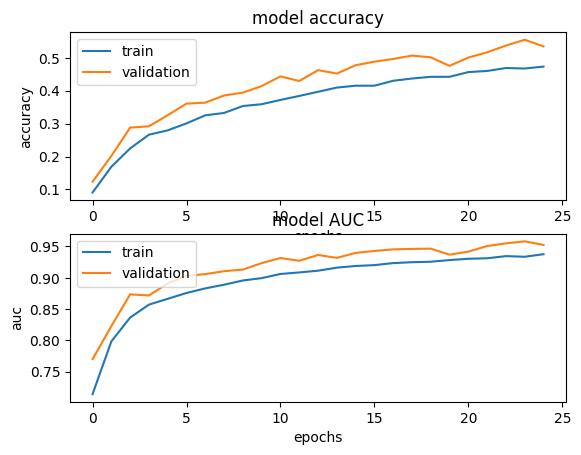

In [20]:
#plot the graphs
fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax1.plot(history.history['categorical_accuracy'])
ax1.plot(history.history['val_categorical_accuracy'])
ax1.set_title('model accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['train','validation'], loc='upper left')

ax2 = fig.add_subplot(2,1,2)
ax2.plot(history.history['auc'])
ax2.plot(history.history['val_auc'])
ax2.set_title('model AUC')
ax2.set_xlabel('epochs')
ax2.set_ylabel('auc')
ax2.legend(['train','validation'], loc='upper left')

plt.show()



In [21]:
test_steps_per_epoch = math.ceil(validation_iterator.samples/validation_iterator.batch_size)
predictions = model.predict(training_iterator,steps = test_steps_per_epoch)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_iterator.classes
class_labels = list(validation_iterator.class_indices.keys())
report = classification_report(true_classes,predicted_classes,target_names=class_labels,zero_division=0)
print(report)

688/688 ━━━━━━━━━━━━━━━━━━━━ 122s 177ms/step
                  precision    recall  f1-score   support

african_elephant       0.03      0.03      0.03       348
          alpaca       0.02      0.01      0.02       333
  american_bison       0.04      0.05      0.04       343
        anteater       0.02      0.02      0.02       299
      arctic_fox       0.01      0.00      0.00       315
       armadillo       0.03      0.03      0.03       331
          baboon       0.02      0.02      0.02       330
          badger       0.03      0.03      0.03       310
      blue_whale       0.01      0.01      0.01       243
      brown_bear       0.02      0.01      0.02       300
           camel       0.01      0.01      0.01       254
         dolphin       0.03      0.02      0.02       311
         giraffe       0.03      0.02      0.03       305
       groundhog       0.01      0.01      0.01       309
 highland_cattle       0.01      0.02      0.01       311
           horse       0.0

In [22]:
cm = confusion_matrix(true_classes,predicted_classes)
print(cm)


[[10  4 12 ... 16  5  6]
 [ 5  4 13 ... 20  7  8]
 [12  3 17 ... 21  7  6]
 ...
 [10  2  9 ... 11  4 11]
 [11  4  8 ... 10  5  2]
 [ 4  5  7 ... 12  2  5]]


In [27]:
#test using an image
image_path = 'test/bear.jpg'
img  = image.load_img(image_path,target_size=(256,256),color_mode='rgb')
img_arr = image.img_to_array(img)
img_arr = img_arr/255.0
img_arr = np.expand_dims(img_arr, axis=0)


In [28]:
prediction = model.predict(img_arr, verbose=1)
predicted_class = np.argmax(prediction[0])
class_labels = list(training_iterator.class_indices.keys())
print(class_labels[predicted_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
polar_bear
